In [1]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch
import torch.nn.functional as F

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

/home/vast/CE-relevance-integration/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/vast/CE-relevance-integration/.venv/lib/python3.10/site-packages/transformers/utils/hub.py:124: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [2]:


model = AutoModelForSequenceClassification.from_pretrained("xpmir/cross-encoder-bert-base-infoNCE")
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

/home/vast/CE-relevance-integration/.venv/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/home/vast/CE-relevance-integration/.venv/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [3]:
import gc
from typing import List, Optional, Dict, Iterable, Callable

def filter_module(module: str, keywords: List[str]):
    return any(word in module for word in keywords)

def untuple(x):
    return x[0] if isinstance(x, tuple) else x

def get_interesting_modules(model, list_regex: Optional[List[str]] = None) -> Dict:
    """
    Returns a dictionnary containing the name of the interesting modules in the model.

    :return Dict: Dictionnary where the key is the module's name and the value is the number of out features.
    """
    interesting_layers = ["output.dense", "LayerNorm"]
    neurons_per_layers = dict() 
    for name, module in model.named_modules():
        if any(word in name for word in interesting_layers):
            if list_regex is not None:
                if filter_module(name, list_regex):
                    if hasattr(module, 'out_features'):
                        neurons_per_layers[name] = module.out_features
                    else:
                        # This corresponds to the dropout which is in fact used to target the attention_probs of shape [batch_size, num_heads, seq_length, seq_length].
                        # So number of neurons here is: num_heads * seq_length.
                        neurons_per_layers[name] = model.config.num_attention_heads
            else:
                if hasattr(module, 'out_features'):
                    neurons_per_layers[name] = module.out_features
                else:
                    neurons_per_layers[name] = model.config.num_attention_heads
                    

    return neurons_per_layers

class OutputsExtractor(torch.nn.Module):
    # SAme as InputsExtractor but to extract outputs instead
    def __init__(self, model: torch.nn.Module, layer_names: Iterable[str]):
        super().__init__()
        self.model = model
        self.storage = dict()
        self.hooks_handles = list()

        for layer_name in layer_names:
            layer = dict([*self.model.named_modules()])[layer_name]
            if "LayerNorm" in layer_name:
                residual_name = layer_name.replace("output.LayerNorm", "input.LayerNorm")
            else:
                residual_name = None
            self.hooks_handles.append(layer.register_forward_hook(self.save_outputs_hooks(layer_name, residual_name)))

    @property
    def items(self):
        return self.storage
    
    def save_outputs_hooks(self, layer_name, residual_name) -> Callable:
        def hook(_, inputs, output):
            if residual_name is not None:
                self.storage[residual_name] = untuple(inputs[0])
            self.storage[layer_name] = untuple(output) # Store it and prepares it for backprop
        return hook
    
    def remove_hooks(self):
        for handle in self.hooks_handles:
            handle.remove()
    
    def clear_items(self):
        del self.storage
        gc.collect()
        torch.cuda.empty_cache()
        self.storage = dict()
    
    def forward(self, inputs):
        model_outputs = self.model(**inputs)
        return model_outputs

In [4]:
import re

def keep_last_two_parts(input_string):
    parts = input_string.split('.')
    return '.'.join(parts[-2:])

def keep_parts_after_layer(input_string):
    parts = input_string.split('.')
    for i, part in enumerate(parts):
        if re.match(r'^\d+$', part):  # Check if the part is a number
            return '.'.join(parts[i:])
    return input_string  # Return the original string if no number is found

In [5]:

layer_names = get_interesting_modules(
    model=model,
    list_regex=["output.dense", "output.LayerNorm"]
)

extractor = OutputsExtractor(
    model=model,
    layer_names=layer_names.keys()
)

In [6]:
from typing import Tuple, List

def split_list_by_values(lst: List, values: List) -> List:
    """
    Split a list of integers based on specified values.

    :param List lst: List of integers to be split.
    :param List values: List of values to use as split points.
    :return List: A list of lists where the original list is split at each specified value.
    """
    result = []
    current_chunk = []

    for item in lst:
        current_chunk.append(item)
        if item in values:
            if current_chunk:
                result.append(current_chunk)
                current_chunk = []

    if current_chunk:
        result.append(current_chunk)

    return result

def get_token_types_spans(input, tokenizer) -> List[Tuple]:
    """Returns a list of spans corresponding to the positions in the input
    of respectively, the CLS token, the query's tokens, the document's tokens and the SEP tokens.

    """
    slices = [slice(0,1)] # Initiate the spans with the position of the CLS token
    input_splitted = split_list_by_values(np.array(input[0].cpu()), [tokenizer.sep_token_id])
    query_len = len(input_splitted[0]) - 2 # -1 to account for the CLS token and the first SEP token
    document_len = len(input_splitted[1]) - 1 # -1 to account for the second SEP token
    slices.append(slice(1, query_len + 1)) # The query's tokens
    slices.append(slice(query_len + 1, query_len + 2)) # The first SEP token
    slices.append(slice(query_len + 2, query_len + 2 + document_len)) # The document's tokens
    slices.append(slice(query_len + 2 + document_len, query_len + 2 + document_len + 1)) # The second SEP token
    return slices

# Relevant label

In [21]:
import json
from datamaestro import prepare_dataset
from datamaestro_text.data.ir import TextItem
from tqdm import tqdm

# Defines the parameters
dataset_name = "beir.msmarco.test"
qrels = prepare_dataset('irds.' + dataset_name + '.qrels')
passages = prepare_dataset('irds.' + dataset_name)
topics = prepare_dataset('irds.' + dataset_name + '.queries')
target_count = 100
target_label = 0 # Fixed, we only want the proba of relevance
pred = 0
filter_sample = True
target_relevance_level = 0

count = 0
global_storage = dict()
for qrel in qrels.iter():
    query = topics.topic_ext(qrel.topic_id)
    for assessment in qrel.assessments:
        if assessment.rel == target_relevance_level:
            passage = passages.documents.document_ext(assessment.doc_id)
            inputs = tokenizer(
                query[TextItem].text, 
                passage[TextItem].text,
                max_length=128, # True max length is 512 but it gets too long to compute
                truncation=True,
                padding="max_length", # To get every sample to the same size
                return_attention_mask=True,
                return_tensors="pt"
            )
            inputs.requires_grad = False
            outputs = extractor(inputs)
            pred_label = int(torch.round(F.sigmoid(outputs.logits)))
            spans = get_token_types_spans(inputs["input_ids"], tokenizer)

            if pred_label == pred:
                for key, value in extractor.storage.items():
                    layer_nb = int(key.split(".")[3])
                    cls_token = value[:,spans[0],:]
                    sep_1_token = value[:,spans[2],:]
                    sep_2_token = value[:,spans[4],:]
                    proba = F.sigmoid(model.classifier(model.bert.pooler(cls_token)))
                    proba_value = proba[0][target_label].detach().cpu()
                    if key in global_storage.keys():
                        global_storage[key]['sum'] += proba_value
                        global_storage[key]['sum_sq'] += proba_value ** 2
                    else:
                        global_storage[key] = {'sum': proba_value, 'sum_sq': proba_value ** 2}
                extractor.clear_items()
                count += 1
            if count == target_count:
                break
    if count == target_count:
        break

for key, value in global_storage.items():
    mean = value['sum'] / count
    variance = (value['sum_sq'] / count) - (mean ** 2)
    global_storage[key] = {'mean': float(mean), 'variance': float(variance)}

# # Save global_storage to a json file
with open(f'./storage_relevance-{target_relevance_level}_filter-{filter_sample}_count-{target_count}.json', 'w') as file:
    json.dump(global_storage, file)
# with open(f'/home/vast/relevance-integration/relevance_integration_xps/sep_1-{target_relevance_level}_filter-{filter_sample}_count-{target_count}.json', 'w') as file:
#     json.dump(global_storage, file)


[INFO] Opening /home/vast/.ir_datasets/beir/msmarco/docs.pklz4/bin with MMAP


In [22]:
import json
from datamaestro import prepare_dataset
from datamaestro_text.data.ir import TextItem
from tqdm import tqdm

# Defines the parameters
dataset_name = "beir.msmarco.test"
qrels = prepare_dataset('irds.' + dataset_name + '.qrels')
passages = prepare_dataset('irds.' + dataset_name)
topics = prepare_dataset('irds.' + dataset_name + '.queries')
target_count = 100
target_label = 0 # Fixed, we only want the proba of relevance
pred = 0
filter_sample = True
target_relevance_level = 3

count = 0
global_storage = dict()
for qrel in qrels.iter():
    query = topics.topic_ext(qrel.topic_id)

    for i in range(3):
        pid = int(np.random.randint(0, passages.documents.documentcount))
        
        passage = passages.documents.document_int(pid)
        inputs = tokenizer(
            query[TextItem].text, 
            passage[TextItem].text,
            max_length=128, # True max length is 512 but it gets too long to compute
                truncation=True,
                padding="max_length", # To get every sample to the same size
                return_attention_mask=True,
                return_tensors="pt"
            )
        inputs.requires_grad = False
        outputs = extractor(inputs)
        pred_label = int(torch.argmax(F.sigmoid(outputs.logits)))
        spans = get_token_types_spans(inputs["input_ids"], tokenizer)

        if pred_label == pred:
            for key, value in extractor.storage.items():
                layer_nb = int(key.split(".")[3])
                cls_token = value[:,spans[0],:]
                sep_1_token = value[:,spans[2],:]
                sep_2_token = value[:,spans[4],:]
                proba = F.sigmoid(model.classifier(model.bert.pooler(cls_token)))
                proba_value = proba[0][target_label].detach().cpu()
                if key in global_storage.keys():
                    global_storage[key]['sum'] += proba_value
                    global_storage[key]['sum_sq'] += proba_value ** 2
                else:
                    global_storage[key] = {'sum': proba_value, 'sum_sq': proba_value ** 2}
            extractor.clear_items()
            count += 1
        if count == target_count:
            break
    if count == target_count:
        break

for key, value in global_storage.items():
    mean = value['sum'] / count
    variance = (value['sum_sq'] / count) - (mean ** 2)
    global_storage[key] = {'mean': float(mean), 'variance': float(variance)}

# # Save global_storage to a json file
with open(f'./weak_negatives_count-{target_count}.json', 'w') as file:
    json.dump(global_storage, file)
# with open(f'/home/vast/relevance-integration/relevance_integration_xps/sep_1-{target_relevance_level}_filter-{filter_sample}_count-{target_count}.json', 'w') as file:
#     json.dump(global_storage, file)


Reading data from file: ./weak_negatives_count-100.json
['0.attention.output.dense', '0.attention.output.LayerNorm', '0.output.dense', '0.output.LayerNorm', '1.attention.output.dense', '1.attention.output.LayerNorm', '1.output.dense', '1.output.LayerNorm', '2.attention.output.dense', '2.attention.output.LayerNorm', '2.output.dense', '2.output.LayerNorm', '3.attention.output.dense', '3.attention.output.LayerNorm', '3.output.dense', '3.output.LayerNorm', '4.attention.output.dense', '4.attention.output.LayerNorm', '4.output.dense', '4.output.LayerNorm', '5.attention.output.dense', '5.attention.output.LayerNorm', '5.output.dense', '5.output.LayerNorm', '6.attention.output.dense', '6.attention.output.LayerNorm', '6.output.dense', '6.output.LayerNorm', '7.attention.output.dense', '7.attention.output.LayerNorm', '7.output.dense', '7.output.LayerNorm', '8.attention.output.dense', '8.attention.output.LayerNorm', '8.output.dense', '8.output.LayerNorm', '9.attention.output.dense', '9.attention.ou

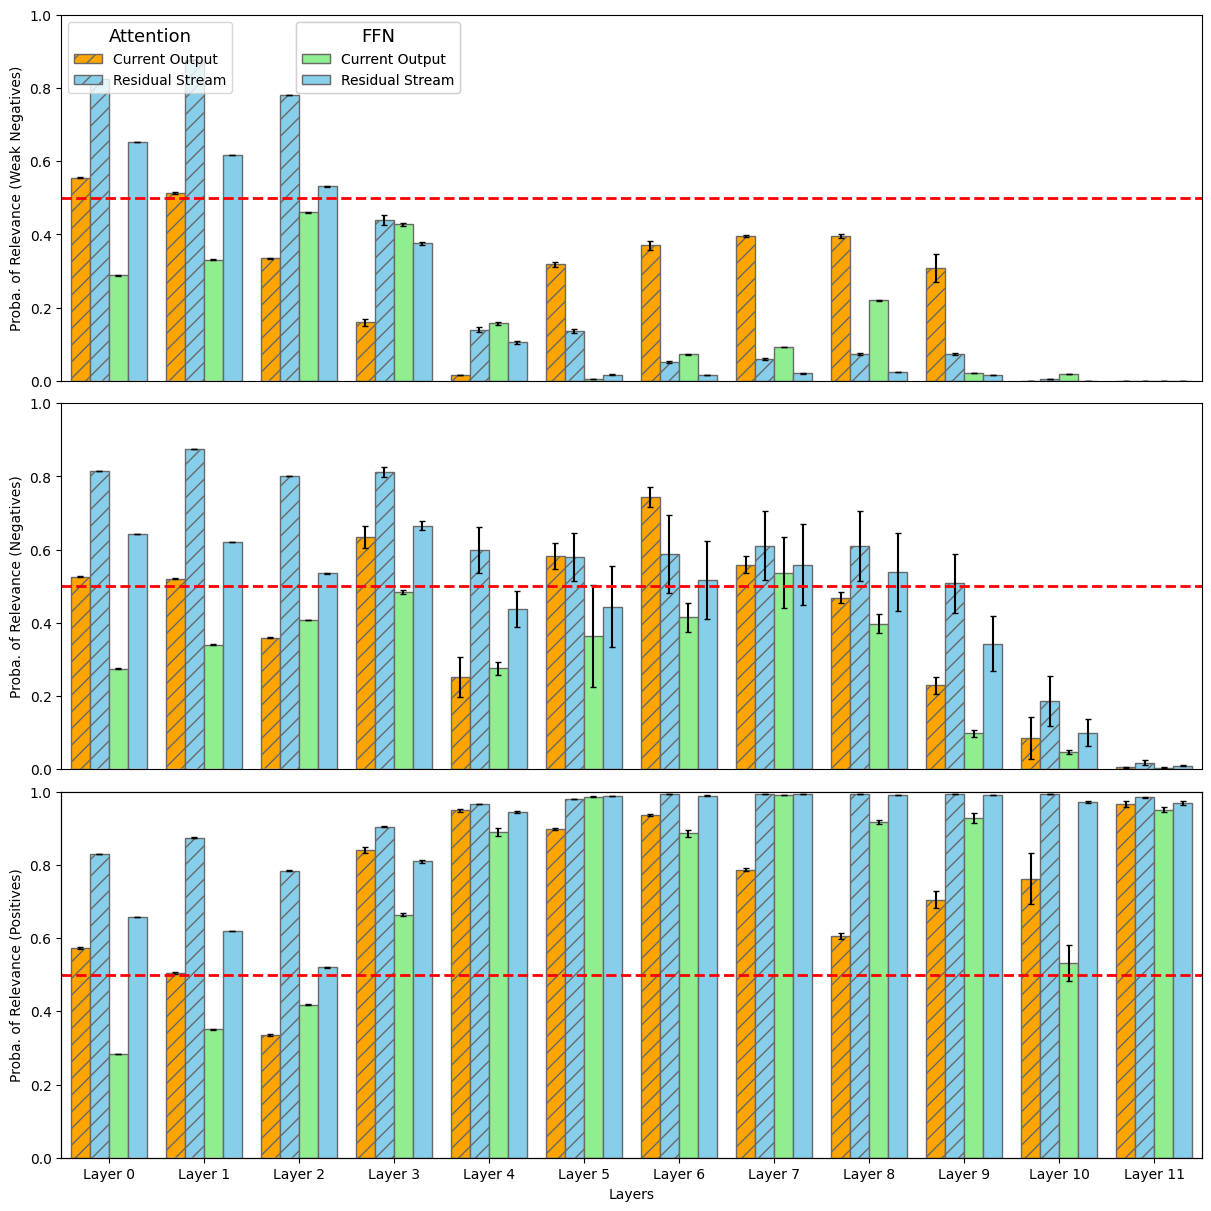

In [8]:
import matplotlib.pyplot as plt
import re
import json
from matplotlib.patches import Patch

target_count = 100
filter_sample = True
target_relevance_level = 0

# Create the plot
fig, axes = plt.subplots(3, 1, figsize=(12, 12), constrained_layout=True)
default_color = 'skyblue'
highlight_color_attention = 'orange'
highlight_color_ffn = 'lightgreen'
residual_color = "lightgrey"

# Define hatch styles
default_hatch = ''
highlight_hatch_attention = '//'

for idx, relevance_level in enumerate([-1,0,3]):
    if relevance_level == -1:
        filename = f'weak_negatives_count-{target_count}.json'
    else:
        filename = f'storage_relevance-{relevance_level}_filter-{filter_sample}_count-{target_count}.json'

    # Read the corresponding JSON file
    print(f"Reading data from file: ./{filename}")
    with open(f"./{filename}", 'r') as file:
        global_storage = json.load(file)

    # Assuming global_storage is already defined and contains mean and variance for each module
    relevance_level += 1 # After having loaded the data, we increment the relevance level to match the axes index
    means = []
    variances = []
    filter_layers = [i for i in range(0, 12)]

    for key, value in global_storage.items():
        if int(key.split('.')[3]) in filter_layers and not "input" in key:
            means.append(value['mean'])
            variances.append(value['variance'])

    # Function to keep parts after the layer number
    def keep_parts_after_layer(input_string):
        parts = input_string.split('.')
        for i, part in enumerate(parts):
            if re.match(r'^\d+$', part):  # Check if the part is a number
                return '.'.join(parts[i:])
        return input_string  # Return the original string if no number is found

    # Create layer labels and module labels
    modules_per_layer = 4
    layers = [f'Layer {i//modules_per_layer+filter_layers[0]}' for i in range(len(filter_layers) * modules_per_layer)]
    modules = [keep_parts_after_layer(key) for key in global_storage.keys() if 'input' not in key and int(key.split('.')[3]) in filter_layers]
    print(modules)
    # Plot bars with different colors and hatch styles for specific modules
    for i, module in enumerate(modules):
        if "attention" in module and not "LayerNorm" in module:
            color = highlight_color_attention
        elif not "attention" in module and not "LayerNorm" in module:
            color = highlight_color_ffn
        else:
            color = default_color

        if "attention" in module:
            hatch = highlight_hatch_attention
        else:
            hatch = default_hatch

        # Adjust index to account for spaces
        adjusted_index = i + 1 * (i // modules_per_layer)
        axes[idx].bar(adjusted_index, means[i], width=1, color=color, yerr=abs(variances[i]), capsize=2, hatch=hatch, edgecolor='dimgray')

    # Add spaces between layers by adding empty bars
    for i in range(1, filter_layers[-1] - filter_layers[0] + 1):
        axes[idx].bar(i, 0, color='white', edgecolor='white')

    # Add a horizontal line at 0.5
    axes[idx].axhline(y=0.5, color='red', linestyle='--', linewidth=2)

    # Add labels and title
    if relevance_level-1 == 0:
        rel = "Negatives"
    elif relevance_level-1 == 3:
        rel = "Positives"
    elif relevance_level-1 == -1:
        rel = "Weak Negatives"
    axes[idx].set_ylabel('Proba. of Relevance (' + rel + ')')
    axes[idx].set_ylim(0, 1)  # Assuming probabilities are between 0 and 1

    # Remove custom tick positions and labels for modules
    axes[idx].set_xticks([])
    # Adjust x-axis limits to reduce spaces before the first bar and after the last one
    axes[idx].set_xlim(-1, adjusted_index + 1)

legend_handles_attention = [
    Patch(facecolor=highlight_color_attention, hatch=highlight_hatch_attention, edgecolor='dimgray', label='Current Output'),
    Patch(facecolor=default_color, hatch=highlight_hatch_attention, edgecolor='dimgray', label='Residual Stream')
]

legend_handles_ffn = [
    Patch(facecolor=highlight_color_ffn, edgecolor='dimgray', label='Current Output'),
    Patch(facecolor=default_color, edgecolor='dimgray', label='Residual Stream')
]

# Add the legends to the plot
legend1 = axes[0].legend(handles=legend_handles_attention, loc='upper left', title='Attention', title_fontsize='13')
legend2 = axes[0].legend(handles=legend_handles_ffn, loc='upper left', title='FFN', bbox_to_anchor=(0.2, 1), title_fontsize='13')

# Add the legends to the plot
axes[0].add_artist(legend1)
axes[0].add_artist(legend2)

# Create a second x-axis for the layers
ax2 = axes[-1].twiny()
ax2.set_xlim(axes[-1].get_xlim())
ax2.set_xticks([i * 5 +1.5 for i in range(filter_layers[-1] - filter_layers[0]+1)])  # Adjust positions for the spaces
ax2.set_xticklabels([f'Layer {i}' for i in filter_layers], rotation=0, ha='center')
ax2.xaxis.set_ticks_position('bottom')
ax2.xaxis.set_label_position('bottom')
ax2.spines['bottom'].set_position(('outward', 0))
ax2.set_xlabel('Layers')

# Show the plot
plt.savefig(f'./monobert_base_relevance_integration_CLS_MSMARCO_FINAL.pdf', format="pdf")
plt.show()